# Inverted Pendulum on a Linear Rail — Sizing Simulation

**Configuration under test**

| Parameter | Value |
|---|---|
| Pendulum length | 100 mm |
| Linear stroke | 500 mm |
| Motor | NEMA 17, 12 V, 3 A limit |
| Drive | Belt, 14 mm pitch-diameter pulley |

This notebook answers three questions:

1. **Is the rail long enough?** — can the cart swing the pendulum up and catch it without running out of track?
2. **Is the motor fast and strong enough?** — do the velocity and acceleration ceilings permit swing-up?
3. **Is the pendulum slow enough to control with a camera?** — can a vision loop keep up with how fast it falls?

Everything is derived from first principles before any number is computed. If your physics is
rusty, read the theory sections — they assume nothing beyond Newton's second law.

---

## Notation used throughout

| Symbol | Meaning | Units |
|---|---|---|
| $x$ | cart position along the rail | m |
| $v = \dot{x}$ | cart velocity | m/s |
| $a = \ddot{x}$ | cart acceleration — **this is our control input** | m/s² |
| $\theta$ | pendulum angle, measured **from vertical-up** | rad |
| $\dot{\theta}$ | angular velocity | rad/s |
| $L$ | physical length of the pendulum rod | m |
| $m$ | mass of the rod | kg |
| $l$ | distance from pivot to the rod's centre of mass | m |
| $I_p$ | moment of inertia of the rod **about the pivot** | kg·m² |
| $g$ | gravitational acceleration, 9.81 | m/s² |

A dot means a time derivative: $\dot{\theta} = d\theta/dt$, $\ddot{\theta} = d^2\theta/dt^2$.


---
# Part 1 — Why an inverted pendulum is hard

## 1.1 Stable vs unstable equilibrium

A pendulum hanging **down** is at a *stable* equilibrium. Nudge it and gravity pulls it back.
It oscillates and eventually settles.

A pendulum balanced **up** is at an *unstable* equilibrium. Nudge it and gravity pulls it
*further away*. Nothing restores it. Left alone it falls.

The mathematical difference is a single sign, and that sign is the whole problem. For the
hanging case the equation looks like

$$\ddot{\theta} = -\omega_n^2\,\theta \qquad\Rightarrow\qquad \theta(t) = A\cos(\omega_n t + \phi)$$

which **oscillates**. For the inverted case:

$$\ddot{\theta} = +\omega_n^2\,\theta \qquad\Rightarrow\qquad \theta(t) = A e^{+\omega_n t} + B e^{-\omega_n t}$$

which **grows exponentially**. The quantity $\tau = 1/\omega_n$ is the *divergence time
constant*: the time for a small tilt to grow by a factor of $e \approx 2.718$.

This single number governs everything downstream — how fast your control loop must run, how
much latency you can tolerate, and whether a camera is fast enough to be useful at all.


## 1.2 Moment of inertia — the rotational analogue of mass

Newton's second law for straight-line motion is $F = ma$. The rotational version is

$$\tau = I\,\ddot{\theta}$$

where $\tau$ is **torque** (rotational force) and $I$ is **moment of inertia** (rotational mass).

Moment of inertia is defined as $I = \int r^2\,dm$ — every scrap of mass contributes in
proportion to the *square* of its distance from the rotation axis. Mass far from the axis
counts much more than mass near it.

**For a uniform rod of mass $m$ and length $L$, rotating about one end:**

$$I_{\text{end}} = \tfrac{1}{3} m L^2$$

*Where this comes from:* put the axis at $r=0$ and let the rod run to $r=L$. Its linear
density is $m/L$, so $dm = (m/L)\,dr$, and

$$I = \int_0^L r^2 \frac{m}{L}\,dr = \frac{m}{L}\cdot\frac{L^3}{3} = \frac{1}{3}mL^2$$

**Centre of mass** of a uniform rod is at its midpoint, so $l = L/2$.

> **Parallel axis theorem** (useful if your pendulum isn't a plain rod): if you know the
> inertia $I_{cm}$ about the centre of mass, then about any parallel axis a distance $d$ away,
> $I = I_{cm} + m d^2$. For a rod, $I_{cm} = \frac{1}{12}mL^2$, and with $d = L/2$ you recover
> $\frac{1}{12}mL^2 + m\frac{L^2}{4} = \frac{1}{3}mL^2$. ✓


## 1.3 Non-inertial frames and the pseudo-force

Here is the conceptual heart of the whole system: **how does moving the cart affect the pendulum?**

Newton's laws only hold in an *inertial* (non-accelerating) reference frame. Our pivot is
bolted to a cart that accelerates, so it is a **non-inertial** frame.

You already know what this feels like. In a bus that accelerates forward, you get pushed
back into your seat. There is no real force pushing you — you're just being left behind by
the accelerating bus. But *from inside the bus*, it is entirely valid to pretend a backward
force exists, provided you use the right value.

The rule: **in a frame accelerating at $\vec{a}$, add a pseudo-force $-m\vec{a}$ to every mass $m$.**

So in the pivot's frame, our pendulum's centre of mass feels:

- real gravity: $(0,\,-mg)$
- pseudo-force: $(-ma,\,0)$

and now we can apply $\tau = I\ddot\theta$ as if the frame were stationary.


## 1.4 Deriving the equation of motion

With $\theta$ measured from straight up, positive leaning toward $+x$, the centre of mass sits at

$$\vec{r} = (l\sin\theta,\ \ l\cos\theta) \quad\text{relative to the pivot}$$

**Torque from gravity.** Torque is $\tau = r_\perp F$, the perpendicular distance times force.
The horizontal offset of the CoM from the pivot is $l\sin\theta$, and gravity $mg$ acts
downward, so

$$\tau_{\text{gravity}} = +\,m\,g\,l\sin\theta$$

The sign is **positive** — leaning right produces a torque that leans it further right. That
is the instability, expressed algebraically.

**Torque from the pseudo-force.** The pseudo-force $-ma$ is horizontal; the perpendicular
distance from the pivot is the *vertical* offset $l\cos\theta$. So

$$\tau_{\text{pseudo}} = -\,m\,a\,l\cos\theta$$

**Torque from friction** at the pivot, opposing motion:

$$\tau_{\text{damping}} = -\,b\,\dot{\theta}$$

**Putting it together:**

$$\boxed{\ I_p\,\ddot{\theta} \;=\; m g l\sin\theta \;-\; m a l\cos\theta \;-\; b\dot{\theta}\ }$$

### Sanity check — does this match physical intuition?

Suppose the pendulum is falling to the right ($\theta > 0$). To catch it you need $\ddot\theta < 0$.
Looking at the equation, you need the $-mal\cos\theta$ term to dominate, which requires $a > 0$:
**accelerate the cart to the right, driving it underneath the falling pendulum.**

That is exactly what you do balancing a broomstick on your palm. The equation agrees with
your hands. ✓


## 1.5 Collapsing to two parameters

Divide the whole equation by $I_p$:

$$\ddot{\theta} = \frac{mgl}{I_p}\sin\theta - \frac{ml}{I_p}a\cos\theta - \frac{b}{I_p}\dot{\theta}$$

Define two lumped constants:

$$\omega_n^2 \equiv \frac{mgl}{I_p}, \qquad c \equiv \frac{b}{I_p}$$

Notice that $\dfrac{ml}{I_p} = \dfrac{1}{g}\cdot\dfrac{mgl}{I_p} = \dfrac{\omega_n^2}{g}$, so the
acceleration term folds into $\omega_n^2$ as well:

$$\boxed{\ \ddot{\theta} = \omega_n^2\left[\sin\theta - \frac{a}{g}\cos\theta\right] - c\,\dot{\theta}\ }$$

**Only two parameters.** Mass and length have vanished into $\omega_n$.

### Why this matters practically

You never have to measure $m$, $l$, or $I_p$ separately. Hang the pendulum downward, give it a
small push, and time the oscillations. The period is $T = 2\pi/\omega_n$, so
$\omega_n = 2\pi/T$ — one stopwatch measurement gives you the parameter.

*(The hanging pendulum has the same $\omega_n$ because the restoring torque is
$-mgl\sin\phi$ with the same coefficients — only the sign flips.)*

**For a uniform rod pivoted at its end**, substitute $l = L/2$ and $I_p = \frac{1}{3}mL^2$:

$$\omega_n^2 = \frac{m g (L/2)}{\frac{1}{3}mL^2} = \frac{3g}{2L}$$

Shorter rod → larger $\omega_n$ → falls faster. A pendulum half as long falls
$\sqrt{2}\approx 1.41\times$ faster.

### Effective length

$$l_{\text{eff}} \equiv \frac{g}{\omega_n^2}$$

is the length of a **point mass on a massless string** with the same dynamics. For a uniform
rod, $l_{\text{eff}} = 2L/3$. This is the length scale that governs how far the cart must move,
so it shows up repeatedly later.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are

g = 9.81   # m/s^2, standard gravity

# =========================================================================
# PENDULUM PARAMETERS
# =========================================================================
L_rod = 0.100          # [m] physical rod length -- THE SPEC: 100 mm

# For a uniform rod pivoted at one end:  omega_n^2 = 3g/(2L)
#   derived in section 1.5 from  l = L/2  and  I_p = (1/3) m L^2
omega_n = np.sqrt(3*g / (2*L_rod))

# Damping. Coming from a real bearing this is small and you measure it from
# a swing-down test. 0.05 1/s is a reasonable placeholder for a decent
# ball-bearing pivot; it barely affects the sizing conclusions.
c_damp = 0.05          # [1/s]

# Derived quantities
T_swing = 2*np.pi/omega_n      # [s]  period of small oscillation (hanging)
tau_div = 1.0/omega_n          # [s]  divergence time constant (inverted)
l_eff   = g/omega_n**2         # [m]  equivalent point-pendulum length

print(f"Rod length            L        = {L_rod*1000:6.1f} mm")
print(f"Natural frequency     omega_n  = {omega_n:6.2f} rad/s")
print(f"Swing period          T        = {T_swing:6.3f} s     <- measure this with a stopwatch")
print(f"Divergence constant   tau      = {tau_div*1000:6.1f} ms    <- how fast it falls")
print(f"Effective length      l_eff    = {l_eff*1000:6.1f} mm    <- = 2L/3 for a uniform rod")


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


ModuleNotFoundError: No module named 'scipy'

### Reading the divergence constant

$\tau \approx 82$ ms means a small tilt grows by a factor of 2.7 every 82 milliseconds.
After a quarter second it has grown ~20×.

Keep that number in mind. In Part 5 we compare it against camera frame rates, and it is the
number that decides whether this build works at all.


---
# Part 2 — The drivetrain: from motor specs to $a_{max}$ and $v_{max}$

The pendulum equation takes cart acceleration $a$ as its input. The motor and pulley never
appear in that equation. They enter in exactly one place: **they limit how large $a$ and $v$
can be.**

## 2.1 Why the cart's own physics doesn't appear

Your motor driver (stepper driver, or an ODrive running field-oriented control) closes a
velocity loop at 10–20 kHz. The pendulum's dynamics happen at ~12 rad/s ≈ 2 Hz. The inner
loop is roughly a thousand times faster.

That means cart mass, belt friction, and motor torque constant are all *inside* a loop that
rejects them long before the pendulum notices. From the pendulum's point of view, the cart
is a pivot that goes where you tell it. All that survives is the saturation:
**how fast** and **how hard** it can go.

## 2.2 Pulley kinematics

A toothed belt does not slip, so cart travel is rigidly tied to pulley rotation.

For a pulley of **pitch diameter** $D$, one revolution advances the belt by its circumference:

$$\text{travel per revolution} = \pi D$$

With $D = 14$ mm this is $\pi \times 14 = 43.98$ mm/rev.

> **Pitch diameter vs tooth count.** For GT2 belt (2 mm tooth pitch), a pulley with $N$ teeth
> has $\pi D = 2N$, so $D = 2N/\pi$. A 14 mm pitch diameter corresponds to
> $N = \pi D/2 = 22$ teeth. Both descriptions are the same pulley.

**Speed:**
$$v = \frac{\text{rpm}}{60}\times \pi D$$

**Force:** torque is force times radius, so $F = \tau_{\text{motor}}/r$ where $r = D/2$:
$$F = \frac{2\,\tau_{\text{motor}}}{D}$$

**The trade-off.** Bigger pulley → more travel per revolution → **more speed, less force**.
Their product is fixed, because power is fixed. You choose where on that curve to sit.


## 2.3 Stepper torque vs speed — why supply voltage matters so much

This is the part that catches people out, and it's the crux of your configuration.

A stepper's torque is proportional to the current in its windings. A chopper driver regulates
that current to a set value — so at rest you get full rated torque.

But a winding is an **inductor**, and an inductor resists changes in current. As the motor
spins faster, the driver must reverse the current more often, and eventually the supply
voltage simply cannot push current in fast enough. Torque falls off.

**Quantitatively.** A winding has resistance $R$ and inductance $\ell$. At electrical frequency
$f$, its impedance is

$$Z = \sqrt{R^2 + (2\pi f \ell)^2}$$

The driver maintains the rated current $I$ as long as the supply can produce it:

$$V \ge I \cdot Z$$

Solve for the frequency where this stops being true — the **corner frequency**:

$$Z_{max} = \frac{V}{I}, \qquad
2\pi f_c \ell = \sqrt{Z_{max}^2 - R^2}, \qquad
f_c = \frac{\sqrt{(V/I)^2 - R^2}}{2\pi \ell}$$

**Electrical to mechanical.** A standard 1.8° stepper has 200 full steps per revolution,
which is **50 electrical cycles** per mechanical revolution (each cycle = 4 full steps). So

$$\text{rpm}_c = f_c \times \frac{60}{50}$$

Below $\text{rpm}_c$ you get full torque. Above it, torque falls roughly as $1/f$.

### The consequence

$V$ appears in the numerator. **Doubling supply voltage roughly doubles your usable speed.**
This is why steppers are normally run at 24–48 V despite being rated at 2–3 V — the rating
is about steady-state heating, the supply voltage is about how fast current can slew.


In [2]:
# =========================================================================
# DRIVETRAIN PARAMETERS
# =========================================================================
PULLEY_PD = 0.014      # [m]  pitch diameter -- THE SPEC: 14 mm
travel_per_rev = np.pi * PULLEY_PD          # [m/rev]
r_pitch = PULLEY_PD / 2                     # [m]  effective lever arm

# --- NEMA 17 electrical characteristics ---------------------------------
# These vary by part number. A ~3 A NEMA 17 is a larger/longer frame; values
# below are representative. CHECK YOUR MOTOR'S DATASHEET and edit these.
V_supply   = 12.0      # [V]   -- THE SPEC
I_rated    = 3.0       # [A]   -- THE SPEC (current cap)
R_winding  = 0.9       # [ohm] per phase
L_winding  = 0.0025    # [H]   per phase  (2.5 mH)
T_holding  = 0.65      # [N*m] holding torque at rated current

# --- moving mass ---------------------------------------------------------
# carriage + pole mount + rod + encoder + belt share. Keep this LOW:
# acceleration scales as 1/m.
m_cart = 0.30          # [kg]

STEPS_PER_REV = 200    # 1.8 deg stepper
ELEC_CYCLES_PER_REV = STEPS_PER_REV / 4     # = 50

def drivetrain_limits(V, I, R, Lw, T_hold, PD, m_cart):
    """Return (v_max [m/s], a_max [m/s^2], rpm_corner) for a stepper + belt drive."""
    Z_max = V / I                                  # largest impedance we can drive
    if Z_max <= R:
        return 0.0, 0.0, 0.0                       # cannot even reach rated current at DC
    X_L = np.sqrt(Z_max**2 - R**2)                 # allowable inductive reactance
    f_corner = X_L / (2*np.pi*Lw)                  # [Hz] electrical
    rpm_corner = f_corner * 60 / ELEC_CYCLES_PER_REV
    v_max = rpm_corner/60 * np.pi*PD               # [m/s]
    F_max = T_hold / (PD/2)                        # [N]  force at the belt
    a_max = F_max / m_cart                         # [m/s^2]
    return v_max, a_max, rpm_corner

v_max, a_max, rpm_c = drivetrain_limits(V_supply, I_rated, R_winding,
                                        L_winding, T_holding, PULLEY_PD, m_cart)

print(f"Travel per revolution   = {travel_per_rev*1000:6.2f} mm/rev")
print(f"Corner speed            = {rpm_c:6.0f} rpm")
print(f"Max cart velocity       = {v_max:6.3f} m/s")
print(f"Belt force              = {T_holding/r_pitch:6.1f} N")
print(f"Max cart acceleration   = {a_max:6.1f} m/s^2   (with {m_cart*1000:.0f} g moving mass)")

Travel per revolution   =  43.98 mm/rev
Corner speed            =    298 rpm
Max cart velocity       =  0.218 m/s
Belt force              =   92.9 N
Max cart acceleration   =  309.5 m/s^2   (with 300 g moving mass)


In [3]:
# ---- How do these change with supply voltage and pulley size? ----------
print("Effect of SUPPLY VOLTAGE (14 mm pulley):")
print(f"  {'V':>5} {'rpm':>7} {'v_max':>9} {'a_max':>10}")
for V in [12, 24, 36, 48]:
    vm, am, rp = drivetrain_limits(V, I_rated, R_winding, L_winding,
                                   T_holding, PULLEY_PD, m_cart)
    print(f"  {V:5.0f} {rp:7.0f} {vm:8.3f}m/s {am:9.1f}m/s2")

print("\nEffect of PULLEY PITCH DIAMETER (12 V):")
print(f"  {'PD':>7} {'teeth':>6} {'v_max':>9} {'a_max':>10}")
for PD in [0.010, 0.014, 0.020, 0.030, 0.040]:
    vm, am, rp = drivetrain_limits(V_supply, I_rated, R_winding, L_winding,
                                   T_holding, PD, m_cart)
    print(f"  {PD*1000:6.0f}mm {PD*np.pi/2/0.002*2/2:5.0f}T {vm:8.3f}m/s {am:9.1f}m/s2")

print("\nNote how speed and acceleration trade against each other:")
print("bigger pulley = faster but weaker. Their product is roughly constant.")

Effect of SUPPLY VOLTAGE (14 mm pulley):
      V     rpm     v_max      a_max
     12     298    0.218m/s     309.5m/s2
     24     607    0.445m/s     309.5m/s2
     36     914    0.670m/s     309.5m/s2
     48    1220    0.895m/s     309.5m/s2

Effect of PULLEY PITCH DIAMETER (12 V):
       PD  teeth     v_max      a_max
      10mm     8T    0.156m/s     433.3m/s2
      14mm    11T    0.218m/s     309.5m/s2
      20mm    16T    0.312m/s     216.7m/s2
      30mm    24T    0.468m/s     144.4m/s2
      40mm    31T    0.624m/s     108.3m/s2

Note how speed and acceleration trade against each other:
bigger pulley = faster but weaker. Their product is roughly constant.


---
# Part 3 — Simulating the system numerically

## 3.1 The state vector

A differential equation solver needs the problem written as **first-order** equations. Our
pendulum equation is second order ($\ddot\theta$), so we split it by treating $\dot\theta$ as
its own state variable. Four states total:

$$\mathbf{s} = \begin{bmatrix} x \\ v \\ \theta \\ \dot{\theta} \end{bmatrix}
\qquad
\dot{\mathbf{s}} = \begin{bmatrix}
v \\
a \\
\dot{\theta} \\
\omega_n^2\left[\sin\theta - \frac{a}{g}\cos\theta\right] - c\dot{\theta}
\end{bmatrix}$$

Read it top to bottom: position changes at the rate of velocity; velocity changes at the rate
of acceleration (our input); angle changes at the rate of angular velocity; and angular
velocity changes according to the physics we derived.

## 3.2 Why RK4 and not simple Euler

The simplest integrator is **forward Euler**: $\mathbf{s}_{k+1} = \mathbf{s}_k + \Delta t\cdot\dot{\mathbf{s}}_k$.
It assumes the derivative is constant across the whole step. For oscillating systems this
systematically *injects* energy — a simulated pendulum will slowly spin up on its own, which
is physically nonsense and will corrupt any conclusion you draw.

**Runge–Kutta 4** samples the derivative four times per step and takes a weighted average:

$$\begin{aligned}
k_1 &= f(\mathbf{s}) \\
k_2 &= f(\mathbf{s} + \tfrac{\Delta t}{2}k_1) \\
k_3 &= f(\mathbf{s} + \tfrac{\Delta t}{2}k_2) \\
k_4 &= f(\mathbf{s} + \Delta t\,k_3) \\
\mathbf{s}_{k+1} &= \mathbf{s}_k + \tfrac{\Delta t}{6}\left(k_1 + 2k_2 + 2k_3 + k_4\right)
\end{aligned}$$

Error scales as $\Delta t^5$ per step instead of $\Delta t^2$. Four times the work per step
buys many orders of magnitude in accuracy. We verify this below with an energy conservation
test — **always do this check before trusting a physics simulation.**


In [4]:
def deriv(s, a, wn, c):
    """Time derivative of the state vector.

    s  : array [x, v, theta, theta_dot]
    a  : commanded cart acceleration [m/s^2]
    wn : omega_n  [rad/s]   -- passed EXPLICITLY, never captured from globals
    c  : damping  [1/s]

    Returns d(s)/dt. This function IS the physics -- everything else is
    bookkeeping around it.
    """
    x, v, th, thd = s
    # The equation derived in section 1.5:
    thdd = wn**2 * (np.sin(th) - (a/g)*np.cos(th)) - c*thd
    return np.array([v, a, thd, thdd])


def rk4_step(s, a, dt, wn, c):
    """One Runge-Kutta 4 integration step."""
    k1 = deriv(s,               a, wn, c)
    k2 = deriv(s + 0.5*dt*k1,   a, wn, c)
    k3 = deriv(s + 0.5*dt*k2,   a, wn, c)
    k4 = deriv(s +     dt*k3,   a, wn, c)
    return s + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


def energy_norm(s, wn):
    """Normalised mechanical energy: +1 upright at rest, -1 hanging at rest.

    E = (1/2) I_p thd^2 + m g l cos(theta).  Divide by I_p and use
    omega_n^2 = mgl/I_p  ->  E_norm = (1/2)(thd/omega_n)^2 + cos(theta)
    """
    return 0.5*(s[3]/wn)**2 + np.cos(s[2])


# ---- VALIDATION: energy must be conserved with no input and no damping ---
# This is the single most important check on any physics simulation. If the
# equations or the integrator were wrong, energy would drift visibly.
s = np.array([0.0, 0.0, 2.0, 0.0])       # start tilted well over
E0 = energy_norm(s, omega_n)
dt = 1e-3
for _ in range(10000):                    # 10 seconds
    s = rk4_step(s, 0.0, dt, omega_n, 0.0)   # zero input, zero damping
drift = abs(energy_norm(s, omega_n) - E0) / abs(E0) * 100

print(f"Energy drift over 10 s of free swinging: {drift:.6f} %")
print("If this were more than ~0.01%, the integrator or the equations would be wrong.")

Energy drift over 10 s of free swinging: 0.000000 %
If this were more than ~0.01%, the integrator or the equations would be wrong.


---
# Part 4 — Control: how the cart decides what to do

To find out how much rail we need, we must actually *balance* the thing. Two controllers,
each solving a different half of the problem.

## 4.1 LQR — catching and holding it near upright

Near upright, $\sin\theta \approx \theta$ and $\cos\theta \approx 1$, so the system becomes **linear**:

$$\ddot{\theta} \approx \omega_n^2\theta - \frac{\omega_n^2}{g}a$$

In standard state-space form $\dot{\mathbf{s}} = A\mathbf{s} + B a$:

$$A = \begin{bmatrix} 0&1&0&0 \\ 0&0&0&0 \\ 0&0&0&1 \\ 0&0&\omega_n^2&0 \end{bmatrix},
\qquad
B = \begin{bmatrix} 0 \\ 1 \\ 0 \\ -\omega_n^2/g \end{bmatrix}$$

**Linear Quadratic Regulator** finds the feedback law $a = -K\mathbf{s}$ that minimises

$$J = \int_0^\infty \left(\mathbf{s}^T Q\, \mathbf{s} + R\,a^2\right) dt$$

In plain terms: $Q$ says how much you dislike each state being away from zero, $R$ says how
much you dislike using control effort. Crank up $Q_{\theta}$ and it will fight hard to keep the
angle small — at the cost of moving the cart further. That trade-off is directly what sets
your rail requirement, which is why $Q$ and $R$ are worth understanding rather than copying.

Solving it requires the **algebraic Riccati equation**; `scipy` does that for us.

## 4.2 Energy pumping — getting it up there in the first place

From hanging down, you cannot simply push toward upright: the cart can't accelerate hard
enough or far enough in one go. Instead you **pump**, like a child on a swing — small pushes
timed to add energy each half-cycle.

**Deriving the pump law.** Normalised energy is $E = \frac{1}{2}(\dot\theta/\omega_n)^2 + \cos\theta$.
Differentiate with respect to time and substitute the equation of motion:

$$\frac{dE}{dt} = \frac{\dot\theta\ddot\theta}{\omega_n^2} - \dot\theta\sin\theta
= \dot\theta\left[\sin\theta - \frac{a}{g}\cos\theta\right] - \dot\theta\sin\theta
= -\frac{a}{g}\,\dot\theta\cos\theta$$

So energy increases when $a$ has the **opposite sign** to $\dot\theta\cos\theta$. That gives us
the control law directly:

$$a = k_E\,(E - 1)\cdot\text{sign}\!\left(\dot\theta\cos\theta\right)$$

$(E-1)$ is negative while we're below the target energy, so this pushes in the
energy-adding direction and naturally stops when $E$ reaches 1 (upright at rest).

We add $-k_x x - k_v v$ to stop the cart drifting off the end of the rail, then hand over to
LQR once the pendulum arrives near upright with manageable speed.


In [5]:
# =========================================================================
# LQR DESIGN
# =========================================================================
# Q penalises state error, R penalises control effort.
# State order: [x, v, theta, theta_dot]
# theta is weighted heavily (20) because keeping the pendulum up is the point;
# x is weighted lightly (1) because we tolerate the cart wandering somewhat.
Q = np.diag([1.0, 0.1, 20.0, 1.0])
R = np.array([[0.05]])

def make_lqr(wn, Q=Q, R=R):
    """Design an LQR controller for a pendulum of natural frequency wn.

    Returns the gain vector K such that  a = -K . s  stabilises the
    linearised system about upright.
    """
    A_lin = np.array([[0, 1, 0,     0],
                      [0, 0, 0,     0],
                      [0, 0, 0,     1],
                      [0, 0, wn**2, 0]])
    B_lin = np.array([[0],
                      [1],
                      [0],
                      [-wn**2/g]])
    P = solve_continuous_are(A_lin, B_lin, Q, R)   # solve Riccati equation
    K = (np.linalg.inv(R) @ B_lin.T @ P).ravel()
    return K, A_lin, B_lin

K, A_lin, B_lin = make_lqr(omega_n)

print("LQR gain K = [x, v, theta, theta_dot]")
print("            ", np.round(K, 3))
print(f"\nControl law: a = -K . s")
print(f"Interpretation: a 1 degree tilt alone commands "
      f"{abs(K[2])*np.deg2rad(1):.2f} m/s^2 of cart acceleration.")

# Check stability: closed-loop eigenvalues must all have negative real parts
eigs = np.linalg.eigvals(A_lin - B_lin @ K.reshape(1,-1))
print(f"\nClosed-loop eigenvalues (all real parts must be < 0):")
for e in eigs:
    print(f"   {e.real:+8.3f} {e.imag:+8.3f}j")

LQR gain K = [x, v, theta, theta_dot]
             [ -4.472  -5.646 -42.574  -5.441]

Control law: a = -K . s
Interpretation: a 1 degree tilt alone commands 0.74 m/s^2 of cart acceleration.

Closed-loop eigenvalues (all real parts must be < 0):
    -69.085   +0.000j
     -4.821   +0.000j
     -1.028   +0.959j
     -1.028   -0.959j


In [6]:
# =========================================================================
# FULL SIMULATION: swing-up from hanging, then balance
# =========================================================================
def simulate(x_max, a_max, v_max, wn=None, Kg=None, c=None,
             k_E=6.0, k_x=6.0, k_v=1.5,
             dt=5e-4, t_end=30.0,
             catch_angle=0.35, hold_time=2.0, record=False):
    """Swing the pendulum up from hanging and try to balance it.

    x_max : [m]      half the usable stroke (cart may move +/- x_max)
    a_max : [m/s^2]  acceleration saturation from the drivetrain
    v_max : [m/s]    velocity saturation from the drivetrain
    wn    : [rad/s]  pendulum natural frequency (defaults to the global)
    Kg    :          LQR gain vector (defaults to the global)

    Returns (success, peak|x|, peak|v|, trace)
    """
    if wn is None: wn = omega_n
    if Kg is None: Kg = K
    if c  is None: c  = c_damp

    # The handover threshold must scale with the pendulum: a fast pendulum
    # arrives at the top with a higher angular rate. 0.5*wn is a good rule.
    catch_rate = 0.5*wn

    s = np.array([0.0, 0.0, np.pi, 0.0])    # start hanging straight down
    hold = 0
    peak_x = peak_v = 0.0
    trace = []

    for i in range(int(t_end/dt)):
        # wrap angle into [-pi, pi] so 'near upright' tests work
        th = np.arctan2(np.sin(s[2]), np.cos(s[2]))
        E  = 0.5*(s[3]/wn)**2 + np.cos(th)

        if abs(th) < catch_angle and abs(s[3]) < catch_rate:
            # --- near upright: hand over to LQR ---
            a = -Kg @ np.array([s[0], s[1], th, s[3]])
            hold += 1
        else:
            # --- energy pumping + cart centring (section 4.2) ---
            a = k_E*(E - 1.0)*np.sign(s[3]*np.cos(th) + 1e-9)
            a += -k_x*s[0] - k_v*s[1]
            hold = 0

        # --- soft wall: brake hard when approaching the rail end ---
        margin = x_max - abs(s[0])
        if margin < 0.04:
            a = -np.sign(s[0]) * a_max * min(1.0, (0.04 - margin)/0.03)

        # --- DRIVETRAIN SATURATION (this is where motor specs bite) ---
        a = float(np.clip(a, -a_max, a_max))
        if s[1] >=  v_max and a > 0: a = 0.0     # cannot go faster forward
        if s[1] <= -v_max and a < 0: a = 0.0     # cannot go faster backward

        s = rk4_step(s, a, dt, wn, c)
        s[1] = np.clip(s[1], -v_max, v_max)

        peak_x = max(peak_x, abs(s[0])); peak_v = max(peak_v, abs(s[1]))
        if record and i % 20 == 0:
            trace.append([i*dt, s[0], s[1], th, s[3], a])

        # hard rail stop
        if abs(s[0]) >= x_max:
            s[0] = np.clip(s[0], -x_max, x_max); s[1] = 0.0

        if hold > int(hold_time/dt):
            return True, peak_x, peak_v, np.array(trace)

    return False, peak_x, peak_v, np.array(trace)

print("Simulation function defined.")

Simulation function defined.


---
# Part 5 — Results for the specified configuration

## 5.1 Does swing-up work with 500 mm of stroke?

A 500 mm stroke means the cart travels from $-250$ mm to $+250$ mm, so `x_max = 0.25`.


In [7]:
X_MAX = 0.25   # [m] half of the 500 mm stroke

ok, px, pv, trace = simulate(X_MAX, a_max, v_max, record=True)

print(f"CONFIGURATION: {L_rod*1000:.0f} mm pendulum, {2*X_MAX*1000:.0f} mm stroke,")
print(f"               {V_supply:.0f} V / {I_rated:.0f} A NEMA 17, {PULLEY_PD*1000:.0f} mm pulley")
print(f"               v_max = {v_max:.3f} m/s, a_max = {a_max:.1f} m/s^2\n")
print(f"Swing-up succeeded : {ok}")
print(f"Peak cart excursion: {px*1000:.1f} mm  (rail used: {2*px*1000:.1f} mm of {2*X_MAX*1000:.0f} mm)")
print(f"Peak cart speed    : {pv:.3f} m/s  (limit {v_max:.3f} m/s)")

CONFIGURATION: 100 mm pendulum, 500 mm stroke,
               12 V / 3 A NEMA 17, 14 mm pulley
               v_max = 0.218 m/s, a_max = 309.5 m/s^2

Swing-up succeeded : True
Peak cart excursion: 143.5 mm  (rail used: 286.9 mm of 500 mm)
Peak cart speed    : 0.218 m/s  (limit 0.218 m/s)


In [8]:
# ---- how much velocity do we actually NEED? ----------------------------
print("Sweeping the velocity ceiling to find the minimum for swing-up:\n")
print(f"{'v_max':>10} {'success':>9} {'peak |x|':>10}")
results = []
for v in [0.05, 0.10, 0.15, 0.18, 0.20, 0.22, 0.25, 0.30, 0.40, 0.60]:
    o, p, _, _ = simulate(X_MAX, a_max, v)
    results.append((v, o, p))
    print(f"{v:9.2f}m/s {str(o):>9} {p*1000:8.1f}mm")

v_needed = min(v for v, o, p in results if o)
print(f"\nMINIMUM velocity for swing-up : {v_needed:.2f} m/s")
print(f"AVAILABLE at {V_supply:.0f} V             : {v_max:.3f} m/s")
print(f"Margin                        : {(v_max/v_needed - 1)*100:+.0f} %")

Sweeping the velocity ceiling to find the minimum for swing-up:

     v_max   success   peak |x|


     0.05m/s     False      9.3mm


     0.10m/s     False     19.5mm


     0.15m/s     False     29.2mm


     0.18m/s      True     91.4mm


     0.20m/s      True    132.0mm


     0.22m/s      True    142.4mm


     0.25m/s      True    131.9mm


     0.30m/s      True    146.9mm
     0.40m/s      True    208.5mm


     0.60m/s      True    178.1mm

MINIMUM velocity for swing-up : 0.18 m/s
AVAILABLE at 12 V             : 0.218 m/s
Margin                        : +21 %


In [9]:
# ---- how much acceleration do we need? ---------------------------------
print("Sweeping the acceleration ceiling (velocity fixed at what we have):\n")
print(f"{'a_max':>12} {'success':>9} {'peak |x|':>10}")
for a in [1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, a_max]:
    o, p, _, _ = simulate(X_MAX, a, max(v_max, 0.25))
    print(f"{a:10.1f}m/s2 {str(o):>9} {p*1000:8.1f}mm")

print(f"\nNote how little acceleration is actually needed, and that you have "
      f"{a_max:.0f} m/s^2.\nAcceleration is NOT your constraint. Velocity is.")

Sweeping the acceleration ceiling (velocity fixed at what we have):

       a_max   success   peak |x|


       1.0m/s2     False    245.9mm


       2.0m/s2      True     98.4mm


       3.0m/s2      True    148.5mm


       5.0m/s2      True    139.1mm


      10.0m/s2      True    118.9mm


      20.0m/s2      True    131.9mm


      50.0m/s2      True    131.9mm


     309.5m/s2      True    131.9mm

Note how little acceleration is actually needed, and that you have 310 m/s^2.
Acceleration is NOT your constraint. Velocity is.


In [10]:
# ---- balance recovery: how far does the cart travel to catch a tilt? ----
def recover(theta0_deg, a_max, v_max, wn=None, Kg=None, c=None,
            dt=5e-4, t_end=3.0):
    """Start tilted at rest near upright, let LQR catch it, record peak |x|."""
    if wn is None: wn = omega_n
    if Kg is None: Kg = K
    if c  is None: c  = c_damp
    s = np.array([0.0, 0.0, np.deg2rad(theta0_deg), 0.0])
    peak = 0.0; v_saturated = False
    for _ in range(int(t_end/dt)):
        th = np.arctan2(np.sin(s[2]), np.cos(s[2]))
        a = float(np.clip(-Kg @ np.array([s[0], s[1], th, s[3]]), -a_max, a_max))
        if s[1] >=  v_max and a > 0: a = 0.0; v_saturated = True
        if s[1] <= -v_max and a < 0: a = 0.0; v_saturated = True
        s = rk4_step(s, a, dt, wn, c); s[1] = np.clip(s[1], -v_max, v_max)
        peak = max(peak, abs(s[0]))
        if abs(th) > 1.2:
            return False, peak, v_saturated
    ok = abs(np.arctan2(np.sin(s[2]),np.cos(s[2]))) < 0.02
    return ok, peak, v_saturated

print("Recovering from a disturbance (pendulum knocked to an angle, cart at rest):\n")
print(f"{'tilt':>8} {'caught':>8} {'peak |x|':>10} {'vel saturated?':>16}")
for d in [5, 10, 15, 20, 30]:
    o, p, vs = recover(d, a_max, v_max)
    print(f"{d:6d}deg {str(o):>8} {p*1000:8.1f}mm {str(vs):>16}")

print(f"\nAnd with an UNLIMITED velocity ceiling, for comparison:")
print(f"{'tilt':>8} {'caught':>8} {'peak |x|':>10}")
for d in [5, 10, 15, 20, 30]:
    o, p, vs = recover(d, a_max, 99.0)
    print(f"{d:6d}deg {str(o):>8} {p*1000:8.1f}mm")

print(f"\nRule of thumb (unlimited velocity): peak|x| ~= 4.2 * l_eff * theta0")
print(f"  l_eff = {l_eff*1000:.1f} mm, so a 20 deg tilt gives "
      f"{4.2*l_eff*np.deg2rad(20)*1000:.0f} mm")

Recovering from a disturbance (pendulum knocked to an angle, cart at rest):

    tilt   caught   peak |x|   vel saturated?
     5deg     True     63.9mm            False


    10deg     True    130.7mm             True
    15deg    False     68.8mm             True
    20deg    False     52.3mm             True
    30deg    False     36.8mm             True

And with an UNLIMITED velocity ceiling, for comparison:
    tilt   caught   peak |x|


     5deg     True     63.9mm
    10deg     True    128.6mm


    15deg     True    194.9mm
    20deg     True    263.7mm


    30deg     True    413.8mm

Rule of thumb (unlimited velocity): peak|x| ~= 4.2 * l_eff * theta0
  l_eff = 66.7 mm, so a 20 deg tilt gives 98 mm


### Read that table carefully

With the real 12 V velocity ceiling, recovery **fails** above a modest tilt — and the
`vel saturated` column tells you why. It is not that the cart lacks force; it has
300+ m/s². It simply **cannot move fast enough** to get underneath a pendulum that is
already falling.

Compare against the unlimited-velocity column: with speed available, the same LQR catches
every one of these tilts, and the excursion follows the tidy rule
$\text{peak}|x| \approx 4.2\,l_{\text{eff}}\,\theta_0$.

This is the single clearest illustration of the theme running through this whole notebook:
**velocity is the binding constraint, not acceleration.**


## 5.2 The vision feasibility check

This is the question that decides whether the whole project works, and it has nothing to do
with the rail.

Recall $\tau = 1/\omega_n$, the time for a tilt to grow by a factor of $e$. A control loop
must observe and react well within that window. The standard engineering rule:

$$\text{total loop latency} \lesssim 0.1\,\tau
\qquad\text{and}\qquad
\text{control rate} \gtrsim 30\,\omega_n \ \text{Hz}$$

**Total loop latency** for a vision system is roughly:

| Stage | Typical |
|---|---|
| Exposure (effective age at midpoint) | 1 ms |
| Sensor readout + USB/CSI transfer | 2–4 ms |
| Driver buffer to userspace | 0.5–1 ms |
| Preprocess (resize, normalise) | 0.5 ms |
| Neural network inference | 1–3 ms |
| Serialise + network + MCU tick phase | 0.5–1 ms |
| **Total** | **~8–12 ms** |

Plus the frame interval itself — at 80 fps that's another 12.5 ms of quantisation.


In [11]:
# =========================================================================
# VISION FEASIBILITY
# =========================================================================
PIPELINE_LATENCY = 0.010     # [s] ~10 ms of processing (see table above)
CAMERA_FPS       = 80.0      # Arducam AR0234 USB3 at 960x600

frame_interval = 1.0/CAMERA_FPS
total_latency  = PIPELINE_LATENCY + frame_interval
budget         = 0.10 * tau_div

print(f"Pendulum divergence constant  tau = {tau_div*1000:6.1f} ms")
print(f"Latency budget (10% of tau)       = {budget*1000:6.1f} ms")
print(f"")
print(f"Camera frame interval @ {CAMERA_FPS:.0f} fps  = {frame_interval*1000:6.1f} ms")
print(f"Processing pipeline               = {PIPELINE_LATENCY*1000:6.1f} ms")
print(f"TOTAL loop latency                = {total_latency*1000:6.1f} ms")
print(f"")
ratio = total_latency/budget
print(f"Latency / budget = {ratio:.2f}x   ", end="")
print("OK" if ratio <= 1.0 else "*** OVER BUDGET ***")
print(f"Required control rate (30*omega_n) = {30*omega_n:.0f} Hz "
      f"(camera gives {CAMERA_FPS:.0f} Hz)")

Pendulum divergence constant  tau =   82.4 ms
Latency budget (10% of tau)       =    8.2 ms

Camera frame interval @ 80 fps  =   12.5 ms
Processing pipeline               =   10.0 ms
TOTAL loop latency                =   22.5 ms

Latency / budget = 2.73x   *** OVER BUDGET ***
Required control rate (30*omega_n) = 364 Hz (camera gives 80 Hz)


In [12]:
# ---- what pendulum length WOULD work with this camera? ------------------
def min_rod_length(total_latency, margin=0.10):
    """Shortest uniform rod whose divergence constant tolerates this latency.

    Need:  total_latency <= margin * tau = margin / omega_n
      =>   omega_n <= margin / total_latency
      =>   3g/(2L) <= (margin/total_latency)^2
      =>   L >= 3g/2 * (total_latency/margin)^2
    """
    return 1.5 * g * (total_latency/margin)**2

L_min = min_rod_length(total_latency)
print(f"With {total_latency*1000:.1f} ms of loop latency, the shortest viable")
print(f"uniform rod is  L = {L_min*1000:.0f} mm\n")

print(f"{'rod':>8} {'omega_n':>9} {'tau':>8} {'budget':>9} {'verdict':>12}")
for Lr in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50, 0.60]:
    wn = np.sqrt(3*g/(2*Lr)); t = 1/wn; b = 0.1*t
    verdict = "OK" if total_latency <= b else ("marginal" if total_latency <= 2*b else "too fast")
    print(f"{Lr*1000:6.0f}mm {wn:8.2f} {t*1000:6.1f}ms {b*1000:7.1f}ms {verdict:>12}")

With 22.5 ms of loop latency, the shortest viable
uniform rod is  L = 745 mm

     rod   omega_n      tau    budget      verdict
    50mm    17.16   58.3ms     5.8ms     too fast
   100mm    12.13   82.4ms     8.2ms     too fast
   150mm     9.90  101.0ms    10.1ms     too fast
   200mm     8.58  116.6ms    11.7ms     marginal
   300mm     7.00  142.8ms    14.3ms     marginal
   400mm     6.07  164.9ms    16.5ms     marginal
   500mm     5.42  184.3ms    18.4ms     marginal
   600mm     4.95  201.9ms    20.2ms     marginal


---
# Part 6 — Trajectory plot

Seeing the swing-up happen makes the numbers concrete: watch the pendulum angle spiral in
toward zero while the cart oscillates to pump energy, then settle once LQR takes over.


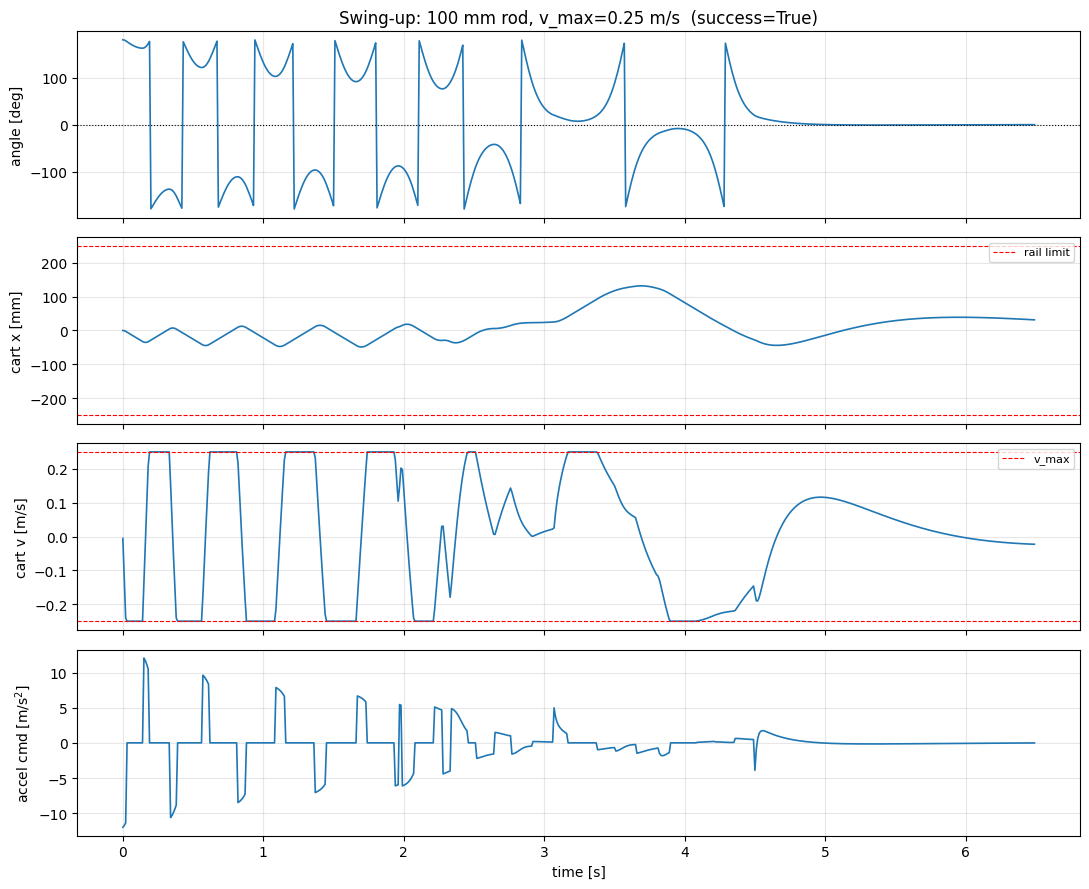

In [13]:
# Use a velocity limit that actually permits swing-up so there is something to plot
v_plot = max(v_max, 0.25)
ok, px, pv, tr = simulate(X_MAX, a_max, v_plot, record=True)

if len(tr) > 0:
    fig, ax = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
    ax[0].plot(tr[:,0], np.rad2deg(tr[:,3]), lw=1.2)
    ax[0].axhline(0, color='k', ls=':', lw=0.8)
    ax[0].set_ylabel('angle [deg]'); ax[0].set_title(
        f'Swing-up: {L_rod*1000:.0f} mm rod, v_max={v_plot:.2f} m/s  (success={ok})')

    ax[1].plot(tr[:,0], tr[:,1]*1000, lw=1.2)
    ax[1].axhline( X_MAX*1000, color='r', ls='--', lw=0.8, label='rail limit')
    ax[1].axhline(-X_MAX*1000, color='r', ls='--', lw=0.8)
    ax[1].set_ylabel('cart x [mm]'); ax[1].legend(loc='upper right', fontsize=8)

    ax[2].plot(tr[:,0], tr[:,2], lw=1.2)
    ax[2].axhline( v_plot, color='r', ls='--', lw=0.8, label='v_max')
    ax[2].axhline(-v_plot, color='r', ls='--', lw=0.8)
    ax[2].set_ylabel('cart v [m/s]'); ax[2].legend(loc='upper right', fontsize=8)

    ax[3].plot(tr[:,0], tr[:,5], lw=1.2)
    ax[3].set_ylabel('accel cmd [m/s$^2$]'); ax[3].set_xlabel('time [s]')
    for a_ in ax: a_.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("No trace recorded.")

---
# Part 7 - Experiment with your own parameters

Everything above is driven by the parameter cells. The helper below wraps the whole analysis
into a single call so you can sweep the design space quickly.

Worth trying:

- **`V=24`** - the single highest-leverage change available to you
- **`PD=0.020`** - trades surplus force for the speed you actually lack
- **`L_rod=0.40`** - a longer pendulum: slower, and far friendlier to a camera loop
- **`m=0.20`** - lighter carriage, more acceleration for free


In [14]:
def analyse(L_rod_, V_, I_, R_, Lw_, Th_, PD_, m_, stroke_,
            fps=80.0, pipeline=0.010, verbose=True):
    """Complete sizing analysis for one configuration.

    Note every quantity is passed explicitly and nothing is read from globals,
    so this is safe to call in a loop with different parameters.
    """
    wn   = np.sqrt(3*g/(2*L_rod_))
    tau  = 1.0/wn
    leff = g/wn**2
    Kg, _, _ = make_lqr(wn)                       # LQR redesigned for THIS pendulum
    vm, am, rpm = drivetrain_limits(V_, I_, R_, Lw_, Th_, PD_, m_)
    xmax = stroke_/2

    ok, px, pv, _ = simulate(xmax, am, vm, wn=wn, Kg=Kg)

    # smallest velocity ceiling that still permits swing-up
    vneed = None
    for vt in np.arange(0.05, 1.51, 0.05):
        o, _, _, _ = simulate(xmax, am, vt, wn=wn, Kg=Kg)
        if o:
            vneed = vt
            break

    lat = pipeline + 1.0/fps
    budget = 0.1*tau

    if verbose:
        print(f"--- L={L_rod_*1000:.0f}mm  {V_:.0f}V/{I_:.0f}A  PD={PD_*1000:.0f}mm  "
              f"stroke={stroke_*1000:.0f}mm  cart={m_*1000:.0f}g ---")
        print(f"  omega_n {wn:5.2f} rad/s   tau {tau*1000:5.1f} ms   l_eff {leff*1000:5.1f} mm")
        print(f"  drivetrain: v_max {vm:5.3f} m/s   a_max {am:6.1f} m/s^2  ({rpm:.0f} rpm)")
        vn_s = f"{vneed:.2f}" if vneed else "  --"
        print(f"  swing-up  : {'YES' if ok else 'NO '}   needs >= {vn_s} m/s   "
              f"uses {2*px*1000:.0f} mm of {stroke_*1000:.0f} mm")
        print(f"  vision    : latency {lat*1000:.1f} ms vs budget {budget*1000:.1f} ms "
              f"-> {'OK' if lat<=budget else 'OVER by %.1fx' % (lat/budget)}")
    return dict(omega_n=wn, tau=tau, v_max=vm, a_max=am, swingup=ok,
                v_needed=vneed, rail_used=2*px, latency=lat, budget=budget)


print("=== THE SPECIFIED CONFIGURATION ===")
analyse(0.100, 12, 3.0, 0.9, 0.0025, 0.65, 0.014, 0.30, 0.500)

print("\n=== same, but 24 V ===")
analyse(0.100, 24, 3.0, 0.9, 0.0025, 0.65, 0.014, 0.30, 0.500)

print("\n=== 300 mm rod, 24 V, 20 mm pulley ===")
analyse(0.300, 24, 3.0, 0.9, 0.0025, 0.65, 0.020, 0.30, 0.500)

print("\n=== 400 mm rod, 24 V, 20 mm pulley, 800 mm stroke ===")
analyse(0.400, 24, 3.0, 0.9, 0.0025, 0.65, 0.020, 0.30, 0.800)

=== THE SPECIFIED CONFIGURATION ===


--- L=100mm  12V/3A  PD=14mm  stroke=500mm  cart=300g ---
  omega_n 12.13 rad/s   tau  82.4 ms   l_eff  66.7 mm
  drivetrain: v_max 0.218 m/s   a_max  309.5 m/s^2  (298 rpm)
  swing-up  : YES   needs >= 0.20 m/s   uses 287 mm of 500 mm
  vision    : latency 22.5 ms vs budget 8.2 ms -> OVER by 2.7x

=== same, but 24 V ===


--- L=100mm  24V/3A  PD=14mm  stroke=500mm  cart=300g ---
  omega_n 12.13 rad/s   tau  82.4 ms   l_eff  66.7 mm
  drivetrain: v_max 0.445 m/s   a_max  309.5 m/s^2  (607 rpm)
  swing-up  : YES   needs >= 0.20 m/s   uses 381 mm of 500 mm
  vision    : latency 22.5 ms vs budget 8.2 ms -> OVER by 2.7x

=== 300 mm rod, 24 V, 20 mm pulley ===


--- L=300mm  24V/3A  PD=20mm  stroke=500mm  cart=300g ---
  omega_n  7.00 rad/s   tau 142.8 ms   l_eff 200.0 mm
  drivetrain: v_max 0.636 m/s   a_max  216.7 m/s^2  (607 rpm)
  swing-up  : YES   needs >= 0.35 m/s   uses 416 mm of 500 mm
  vision    : latency 22.5 ms vs budget 14.3 ms -> OVER by 1.6x

=== 400 mm rod, 24 V, 20 mm pulley, 800 mm stroke ===


--- L=400mm  24V/3A  PD=20mm  stroke=800mm  cart=300g ---
  omega_n  6.07 rad/s   tau 164.9 ms   l_eff 266.7 mm
  drivetrain: v_max 0.636 m/s   a_max  216.7 m/s^2  (607 rpm)
  swing-up  : YES   needs >= 0.45 m/s   uses 462 mm of 800 mm
  vision    : latency 22.5 ms vs budget 16.5 ms -> OVER by 1.4x


{'omega_n': np.float64(6.065269985746718),
 'tau': np.float64(0.16487312227649933),
 'v_max': np.float64(0.6359371038082303),
 'a_max': 216.66666666666669,
 'swingup': True,
 'v_needed': np.float64(0.45),
 'rail_used': np.float64(0.4619614525189787),
 'latency': 0.0225,
 'budget': np.float64(0.016487312227649934)}

---
# Summary of the physics

| Concept | Equation | Where it came from |
|---|---|---|
| Moment of inertia, rod about end | $I_p = \frac{1}{3}mL^2$ | $\int_0^L r^2 (m/L)\,dr$ |
| Pseudo-force in accelerating frame | $-m\vec{a}$ | Newton's laws require an inertial frame |
| Equation of motion | $I_p\ddot\theta = mgl\sin\theta - mal\cos\theta - b\dot\theta$ | torque balance about the pivot |
| Two-parameter form | $\ddot\theta = \omega_n^2[\sin\theta - \frac{a}{g}\cos\theta] - c\dot\theta$ | divide by $I_p$, define $\omega_n^2 = mgl/I_p$ |
| Natural frequency, uniform rod | $\omega_n^2 = 3g/2L$ | substitute $l=L/2$, $I_p=\frac{1}{3}mL^2$ |
| Divergence time constant | $\tau = 1/\omega_n$ | solution of $\ddot\theta = +\omega_n^2\theta$ |
| Effective length | $l_{\text{eff}} = g/\omega_n^2 = 2L/3$ | equivalent point pendulum |
| Belt travel per revolution | $\pi D$ | circumference; belt doesn't slip |
| Belt force | $F = 2\tau_{\text{motor}}/D$ | $\tau = Fr$ with $r = D/2$ |
| Stepper corner speed | $f_c = \frac{\sqrt{(V/I)^2 - R^2}}{2\pi \ell}$ | driver holds current while $V \ge IZ$ |
| Energy pump law | $\frac{dE}{dt} = -\frac{a}{g}\dot\theta\cos\theta$ | differentiate $E$, substitute EOM |
| Recovery excursion | $\text{peak}\,|x| \approx 4.2\,l_{\text{eff}}\,\theta_0$ | empirical, from LQR simulation |
| Latency rule | $t_{\text{latency}} \lesssim 0.1\tau$ | standard control engineering guideline |
